# Admixture Mapping

Admixture mapping tests whether local ancestry at a genomic region is associated with a phenotype in recently admixed individuals. Instead of asking whether a specific SNP allele is associated with a trait, we ask whether carrying ancestry from a source population at a local genomic window changes trait values after accounting for background ancestry and other covariates.

This tutorial, we build a synthetic local ancestry dataset with a quantitative trait, run `snputils.tools.run_admixture_mapping`, and make a Manhattan plot from the resulting association table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from snputils.datasets import build_synthetic_admixture_dataset
from snputils.phenotype.genobj import CovariateObject, PhenotypeObject
from snputils.tools import run_admixture_mapping
from snputils.visualization import manhattan_plot, qq_plot


## What the input represents

A local ancestry inference method usually produces one ancestry label per haplotype per genomic window. For a diploid sample, each window therefore has two ancestry labels: one for each haplotype. `snputils` stores that information in a `LocalAncestryObject`.

For each ancestry and each window, admixture mapping converts those two haplotype labels into an ancestry dosage: 0, 1, or 2 copies of the requested ancestry. The association model then tests whether that dosage is related to the phenotype.

## Build a synthetic dataset

The synthetic trait below has a few sparse local ancestry effects plus global ancestry-like covariates, so the strongest signals should appear near the simulated causal windows while most tests remain null.

`build_synthetic_admixture_dataset` lives in `snputils.datasets`, and returns:

- `laiobj`: local ancestry calls for each haplotype and window.
- `phenotype`: a continuous trait generated from a few local ancestry effects, covariates, and noise.
- `covar_matrix`: covariates that include genome-wide ancestry-like summaries.
- `effect_windows`, `effect_ancestries`, and `effect_sizes`: the simulated ground truth used only for interpretation.


In [2]:
RESULTS_DIR = Path("results/admixture_mapping")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PHENO_NAME = "TRAIT"

synthetic = build_synthetic_admixture_dataset(
    n_samples=2000,
    n_windows=22000,
    n_covariates=3,
    seed=42,
)

laiobj = synthetic["laiobj"]
sample_ids = synthetic["sample_ids"]
phenotype_values = synthetic["phenotype"]
covar_names = synthetic["covar_names"]
covar_matrix = synthetic["covar_matrix"]
covariates = synthetic["covariates"]

print(laiobj)
print(f"Phenotype shape: {phenotype_values.shape}")
print(f"Covariate matrix shape: {covar_matrix.shape}")

LocalAncestryObject(shape=(22000, 4000), n_windows=22000, n_samples=2000, n_haplotypes=4000, n_ancestries=3, has_window_metadata=True, has_ancestry_map=True)
Phenotype shape: (2000,)
Covariate matrix shape: (2000, 3)


The simulated causal windows are shown below. In real data these columns do not exist; they are included here so we can sanity-check whether the analysis recovers the planted signal.


In [8]:
truth = pd.DataFrame({
    "window_index_0_based": synthetic["effect_windows"],
    "chromosome": laiobj.chromosomes[synthetic["effect_windows"]],
    "start": laiobj.physical_pos[synthetic["effect_windows"], 0],
    "end": laiobj.physical_pos[synthetic["effect_windows"], 1],
    "ancestry_code": synthetic["effect_ancestries"],
    "ancestry": [laiobj.ancestry_map[str(code)] for code in synthetic["effect_ancestries"]],
    "effect_size": synthetic["effect_sizes"],
})
truth

,window_index_0_based,chromosome,start,end,ancestry_code,ancestry,effect_size
0,2200,3,5000001,5004999,0,AFR,0.30
1,12099,13,2475001,2479999,1,EUR,-0.26
2,21999,22,24975001,24979999,2,AMR,0.22


## Create phenotype and covariate inputs

`run_admixture_mapping` accepts file paths or in-memory snputils objects. Here we use an in-memory `PhenotypeObject`, `LocalAncestryObject`, and `CovariateObject`.

Covariates are important in real admixture mapping. Local ancestry is correlated across the genome and with global ancestry; without adjustment, a local window can look associated because it tags broader ancestry structure rather than a region-specific effect.

In [4]:
phenotype = PhenotypeObject(
    samples=sample_ids,
    values=phenotype_values,
    phenotype_name=PHENO_NAME,
    quantitative=True,
)

covariates = CovariateObject(
    samples=sample_ids,
    values=covar_matrix,
    covariate_names=covar_names,
)

pd.DataFrame(covariates.values, index=covariates.samples, columns=covariates.covariate_names)


,COV1,COV2,COV3
A00000,-0.330546,0.634283,0.236212
A00001,-0.651705,1.062672,0.336365
A00002,-0.275401,-0.115268,-0.084457
A00003,-0.753692,1.544846,0.866777
A00004,0.401226,0.367596,-0.915346
...,...,...,...
A01995,-0.921008,0.516885,0.657766
A01996,-1.158979,2.452996,2.187145
A01997,1.127358,-1.241836,0.632129
A01998,-0.219785,-0.030625,0.777080


## Run admixture mapping

The API uses `lai_source` for either an MSP path or a `LocalAncestryObject`.

For a quantitative trait, `snputils` fits a linear model per window and ancestry. For a binary trait, it fits a logistic model. The returned table includes p-values, effect estimates, standard errors, test type, ancestry labels, chromosome, position, and multiple-testing adjusted p-values when `adjust=True`.

In [5]:
results_path = RESULTS_DIR / "synthetic_admixture_mapping.tsv.gz"

results = run_admixture_mapping(
    phe_path=phenotype,
    lai_source=laiobj,
    results_path=results_path,
    batch_size=256,
    quantitative=True,
    covar=covariates,
    covar_variance_standardize=True,
    ci=0.95,
    adjust=True,
    keep_hla=True,
    return_results=True,
    verbose=True,
)

results

Reading LAI source (LocalAncestryObject)...
  Chunk 0: 256 windows (total so far: 256)
  Done. Processed 22,000 windows.


,#CHROM,POS,END,ID,REF,ALT,A1,ANCESTRY,TEST,OBS_CT,BETA,SE,T_STAT,P,L95,U95,BONF,FDR_BH,ERRCODE
0,1,1,4999,w1_AFR,N,AFR,AFR,AFR,LINEAR,2000,-0.171130,0.087126,-1.964177,4.964817e-02,-0.341997,-0.000263,1.000000,0.949899,.
1,1,25001,29999,w2_AFR,N,AFR,AFR,AFR,LINEAR,2000,-0.214909,0.086942,-2.471884,1.352322e-02,-0.385415,-0.044404,1.000000,0.869918,.
2,1,50001,54999,w3_AFR,N,AFR,AFR,AFR,LINEAR,2000,-0.223219,0.086726,-2.573841,1.012925e-02,-0.393302,-0.053136,1.000000,0.852834,.
3,1,75001,79999,w4_AFR,N,AFR,AFR,AFR,LINEAR,2000,-0.237153,0.086625,-2.737707,6.241845e-03,-0.407038,-0.067269,1.000000,0.761482,.
4,1,100001,104999,w5_AFR,N,AFR,AFR,AFR,LINEAR,2000,-0.233500,0.086671,-2.694094,7.117167e-03,-0.403476,-0.063525,1.000000,0.792420,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65995,22,24875001,24879999,w21996_AMR,N,AMR,AMR,AMR,LINEAR,2000,0.442430,0.098918,4.472673,8.159219e-06,0.248436,0.636424,0.538508,0.024478,.
65996,22,24900001,24904999,w21997_AMR,N,AMR,AMR,AMR,LINEAR,2000,0.490311,0.100017,4.902289,1.023791e-06,0.294163,0.686459,0.067570,0.006757,.
65997,22,24925001,24929999,w21998_AMR,N,AMR,AMR,AMR,LINEAR,2000,0.483034,0.099555,4.851932,1.317446e-06,0.287791,0.678277,0.086951,0.007723,.
65998,22,24950001,24954999,w21999_AMR,N,AMR,AMR,AMR,LINEAR,2000,0.509389,0.100400,5.073602,4.265379e-07,0.312489,0.706288,0.028152,0.004685,.


## Inspect the result table

Each row is one ancestry-specific test at one local ancestry window. `P` is the nominal association p-value. `BETA` is the estimated change in the quantitative trait per additional copy of that local ancestry, after covariate adjustment.

In [6]:
result_cols = [
    "#CHROM", "POS", "ID", "ANCESTRY", "TEST", "OBS_CT", "BETA", "SE", "P", "ERRCODE"
]
optional_cols = ["L95", "U95", "BONF", "FDR_BH"]
show_cols = [col for col in result_cols + optional_cols if col in results.columns]

results[show_cols].sort_values("P").head(10)


,#CHROM,POS,ID,ANCESTRY,TEST,OBS_CT,BETA,SE,P,ERRCODE,L95,U95,BONF,FDR_BH
6296,3,5000001,w2201_AFR,AFR,LINEAR,2000,0.464202,0.082196,1.861255e-08,.,0.303003,0.625400,0.001228,0.001228
65999,22,24975001,w22000_AMR,AMR,LINEAR,2000,0.534291,0.099897,9.891250e-08,.,0.338377,0.730205,0.006528,0.003264
6299,3,5075001,w2204_AFR,AFR,LINEAR,2000,0.423219,0.082736,3.432297e-07,.,0.260962,0.585477,0.022653,0.004685
6297,3,5025001,w2202_AFR,AFR,LINEAR,2000,0.420844,0.082709,3.952853e-07,.,0.258639,0.583049,0.026089,0.004685
65998,22,24950001,w21999_AMR,AMR,LINEAR,2000,0.509389,0.100400,4.265379e-07,.,0.312489,0.706288,0.028152,0.004685
6305,3,5225001,w2210_AFR,AFR,LINEAR,2000,0.422560,0.083664,4.803442e-07,.,0.258482,0.586638,0.031703,0.004685
6295,3,4975001,w2200_AFR,AFR,LINEAR,2000,0.414107,0.082419,5.499524e-07,.,0.252471,0.575743,0.036297,0.004685
6302,3,5150001,w2207_AFR,AFR,LINEAR,2000,0.416082,0.082915,5.678927e-07,.,0.253473,0.578690,0.037481,0.004685
6306,3,5250001,w2211_AFR,AFR,LINEAR,2000,0.414821,0.083673,7.738177e-07,.,0.250726,0.578917,0.051072,0.005675
65996,22,24900001,w21997_AMR,AMR,LINEAR,2000,0.490311,0.100017,1.023791e-06,.,0.294163,0.686459,0.067570,0.006757


## Manhattan plot

A Manhattan plot places association strength along genomic position. Each point is one local ancestry window for a single ancestry-specific test. Taller points have smaller p-values. The dashed line is a Bonferroni threshold, a strict correction that divides the chosen significance level by the number of tests in that ancestry-specific plot.


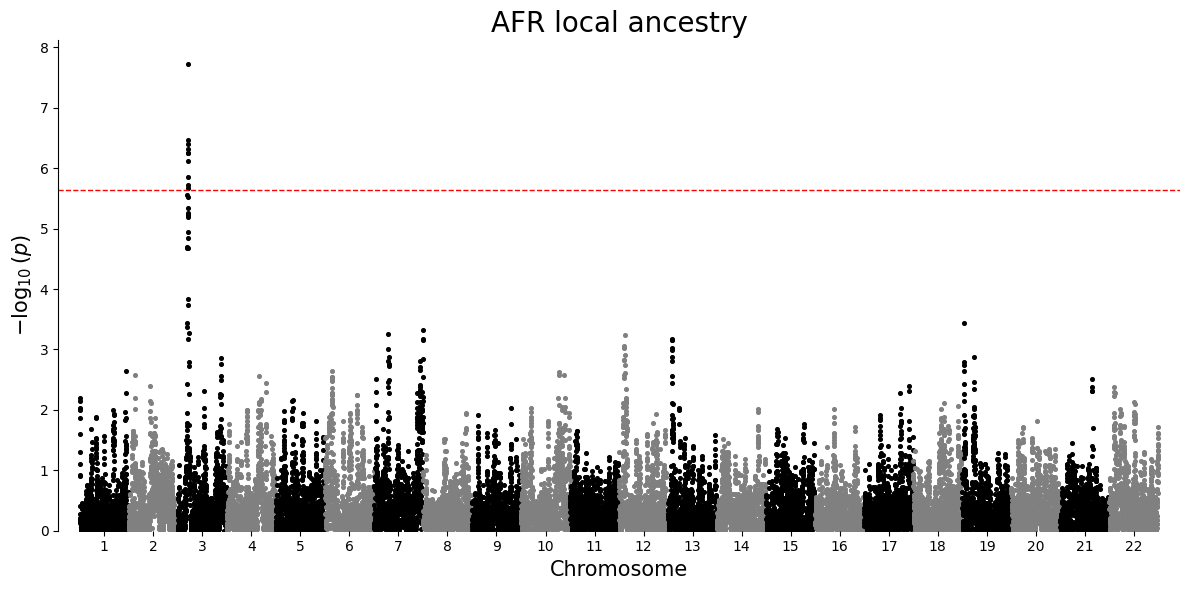

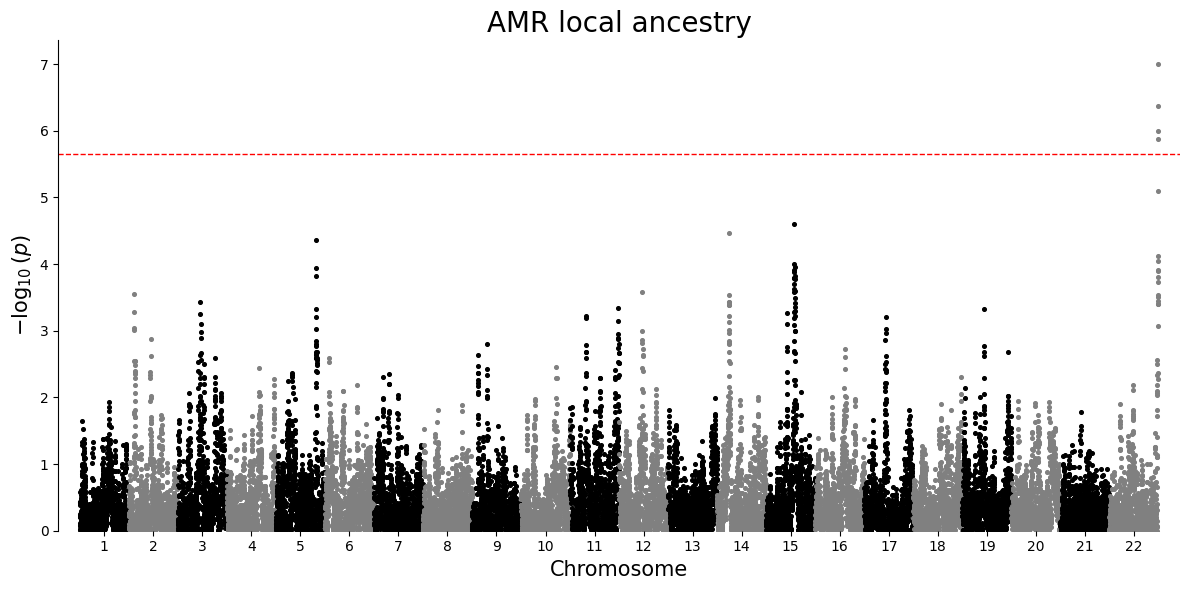

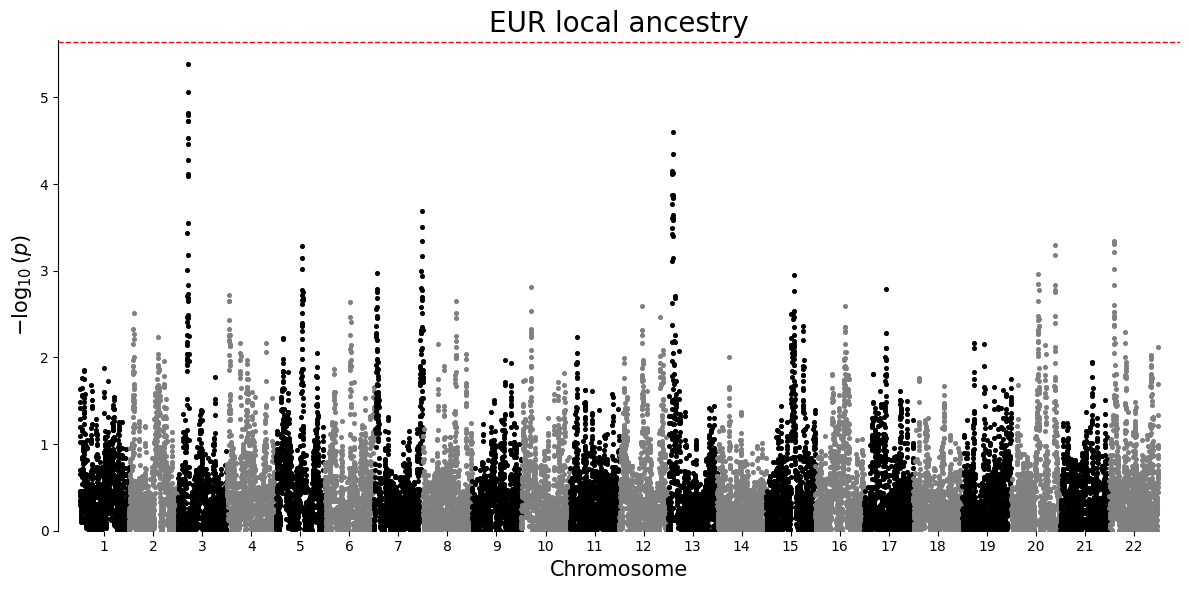

In [10]:
plot_df = results.loc[results["P"].notna() & (results["P"] > 0), ["#CHROM", "POS", "P", "ANCESTRY"]].copy()

for ancestry in sorted(plot_df["ANCESTRY"].unique()):
    ancestry_df = plot_df.loc[plot_df["ANCESTRY"] == ancestry, ["#CHROM", "POS", "P"]].copy()
    manhattan_plot(ancestry_df, title=f"{ancestry} local ancestry")